# Actual results vs. Prophet forecast

## Common utils & setup

In [311]:
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
import logging
import warnings


In [312]:
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

In [313]:
def calc_diffs(actual, prediction):
    actual["ds"] = pd.to_datetime(actual["ds"])
    prediction["ds"] = pd.to_datetime(prediction["ds"])

    # 1. Merge actual and prediction on 'ds'
    df = pd.merge(actual, prediction, on="ds", how="inner")

    # 2. Convert to numeric (just in case)
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["yhat"] = pd.to_numeric(df["yhat"], errors="coerce")

    # 3. Drop NaNs
    df = df.dropna(subset=["y", "yhat"])

    # 4. Absolute difference — allow zeros in both y and yhat
    df["abs_diff"] = (df["yhat"] - df["y"]).abs()

    # 5. Percentage difference — only where y ≠ 0
    df["percent_diff"] = None
    non_zero_mask = df["y"] != 0
    df.loc[non_zero_mask, "percent_diff"] = ((df["yhat"] - df["y"]) / df["y"]).abs() * 100

    # 6. Compute averages
    average_diff = df["abs_diff"].mean()
    average_percent_diff = df["percent_diff"].mean()

    # 7. Print results
    print(f"Average Absolute Difference: {average_diff:.2f}")
    print(f"Average Percentage Difference: {average_percent_diff:.2f}%")

    # 8. Return DataFrame with differences
    return df[["ds", "y", "yhat", "abs_diff", "percent_diff"]], average_diff, average_percent_diff

In [314]:
def plot_actual_vs_pred(df):
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df["ds"], df["y"], label="Actual", linewidth=2)
    plt.plot(df["ds"], df["yhat"], label="Prediction", linewidth=2, linestyle="--")

    # Format
    plt.title("Actual vs. Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show
    plt.show()

In [315]:
# Common date range for actual and prediction
start_date = "2025-02-07 12:00:00"
end_date = "2025-03-09 10:00:00"

## Zone 1

In [316]:
# Load actual data
df_actual = pd.read_csv("../data/pysakoinnit_2025_02_7-2025-03-09.csv") # all zones
df_actual = df_actual[df_actual["zone_id"] == 1] # zone1
# time format "2025-02-07 14:51:10.457393+00"
df_actual['time_start'] = pd.to_datetime(df_actual['time_start'], format="ISO8601")
df_actual['time_end'] = pd.to_datetime(df_actual['time_end'], format="ISO8601")

In [317]:
# Generate hourly timestamps for each hour eg 0, 1, 2
hourly_index = pd.date_range(start=df_actual['time_start'].min().floor('h'),
                             end=df_actual['time_end'].max().ceil('h'),
                             freq='h')

# Initialize an empty DataFrame for hourly occupancy counts
actual_hourly_parking = pd.DataFrame({'ds': hourly_index})

# Count active parkings in each hour
def count_active_parkings(timestamp):
    return ((df_actual['time_start'] <= timestamp) & (df_actual['time_end'] > timestamp)).sum()
    # time stamp is between start and end time of parking

actual_hourly_parking['y'] = actual_hourly_parking['ds'].apply(count_active_parkings)
actual_hourly_parking['ds'] = actual_hourly_parking['ds'].dt.tz_localize(None)
actual_hourly_parking.tail()

,ds,y
739,2025-03-10 06:00:00,70
740,2025-03-10 07:00:00,70
741,2025-03-10 08:00:00,2
742,2025-03-10 09:00:00,1
743,2025-03-10 10:00:00,0


In [318]:
# Load prediction data
df_prediction = pd.read_csv("./data/zone1_baseline_forecast.csv")
df_prediction[["ds", "yhat"]].tail()


,ds,yhat
6971,2025-03-09 07:00:00,118.0
6972,2025-03-09 08:00:00,167.0
6973,2025-03-09 09:00:00,203.0
6974,2025-03-09 10:00:00,220.0
6975,2025-03-09 11:00:00,220.0


In [319]:
# filter actual and prediction dataframes
df_actual_filtered = actual_hourly_parking[(actual_hourly_parking["ds"] >= start_date) & (actual_hourly_parking["ds"] <= end_date)]
df_prediction_filtered = df_prediction[(df_prediction["ds"] >= start_date) & (df_prediction["ds"] <= end_date)]


In [320]:
# Calculate differences
df_diffs, avg_abs_diff, avg_percent_diff = calc_diffs(df_actual_filtered, df_prediction_filtered)

Average Absolute Difference: 52.71
Average Percentage Difference: 44.52%


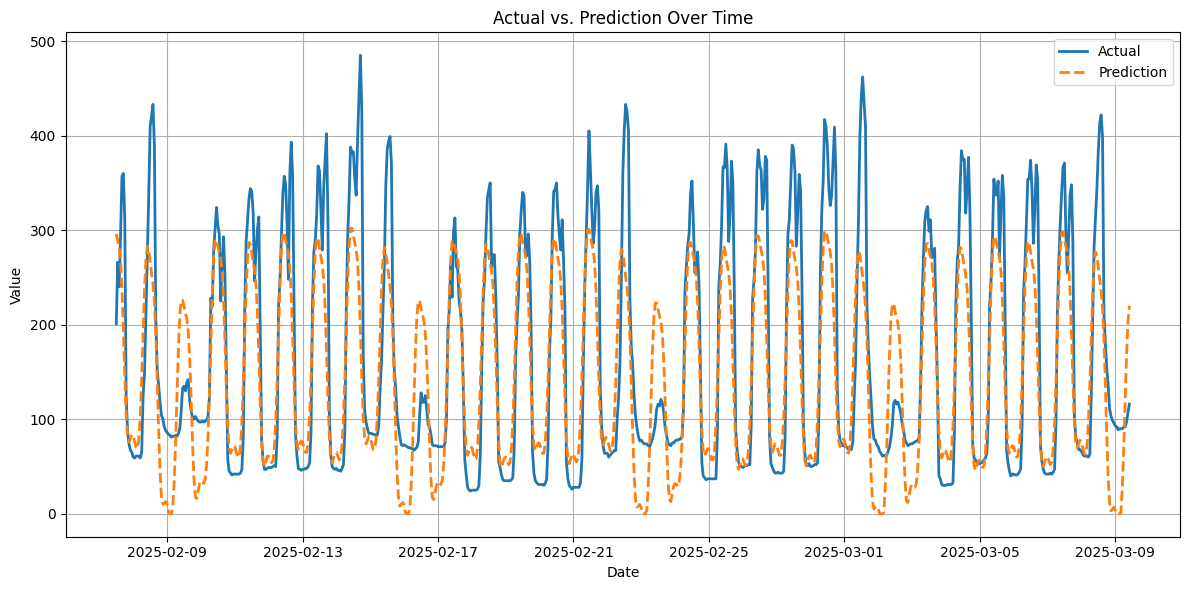

In [321]:
# Plot actual vs. prediction
plot_actual_vs_pred(df_diffs)

## Porthaninkatu 6

In [322]:
# Load actual data
df_actual = pd.read_csv("../data/pysakoinnit_2025_02_7-2025-03-09.csv") # all zones
df_actual = df_actual[df_actual['parking_area_id'] == 'ce8f3960-fc3f-4cc7-87f5-9cd5532e09bc'] # porthaninkatu 6
# time format "2025-02-07 14:51:10.457393+00"
df_actual['time_start'] = pd.to_datetime(df_actual['time_start'], format="ISO8601")
df_actual['time_end'] = pd.to_datetime(df_actual['time_end'], format="ISO8601")

In [323]:
# Generate hourly timestamps for each hour eg 0, 1, 2
hourly_index = pd.date_range(start=df_actual['time_start'].min().floor('h'),
                             end=df_actual['time_end'].max().ceil('h'),
                             freq='h')

# Initialize an empty DataFrame for hourly occupancy counts
actual_hourly_parking = pd.DataFrame({'ds': hourly_index})

# Count active parkings in each hour
def count_active_parkings(timestamp):
    return ((df_actual['time_start'] <= timestamp) & (df_actual['time_end'] > timestamp)).sum()
    # time stamp is between start and end time of parking

actual_hourly_parking['y'] = actual_hourly_parking['ds'].apply(count_active_parkings)
actual_hourly_parking['ds'] = actual_hourly_parking['ds'].dt.tz_localize(None)
actual_hourly_parking.tail()

,ds,y
725,2025-03-09 16:00:00,1
726,2025-03-09 17:00:00,1
727,2025-03-09 18:00:00,1
728,2025-03-09 19:00:00,1
729,2025-03-09 20:00:00,0


In [324]:
# Load prediction data
df_prediction = pd.read_csv("./data/porthaninkatu6_baseline_forecast.csv")
df_prediction[["ds", "yhat"]].tail()

,ds,yhat
7019,2025-03-08 13:00:00,15.0
7020,2025-03-08 14:00:00,9.0
7021,2025-03-08 15:00:00,3.0
7022,2025-03-08 16:00:00,0.0
7023,2025-03-08 17:00:00,0.0


In [325]:
# filter actual and prediction dataframes
df_actual_filtered = actual_hourly_parking[(actual_hourly_parking["ds"] >= start_date) & (actual_hourly_parking["ds"] <= end_date)]
df_prediction_filtered = df_prediction[(df_prediction["ds"] >= start_date) & (df_prediction["ds"] <= end_date)]

In [326]:
# Calculate differences
df_diffs, avg_abs_diff, avg_percent_diff = calc_diffs(df_actual_filtered, df_prediction_filtered)

Average Absolute Difference: 6.58
Average Percentage Difference: 220.42%


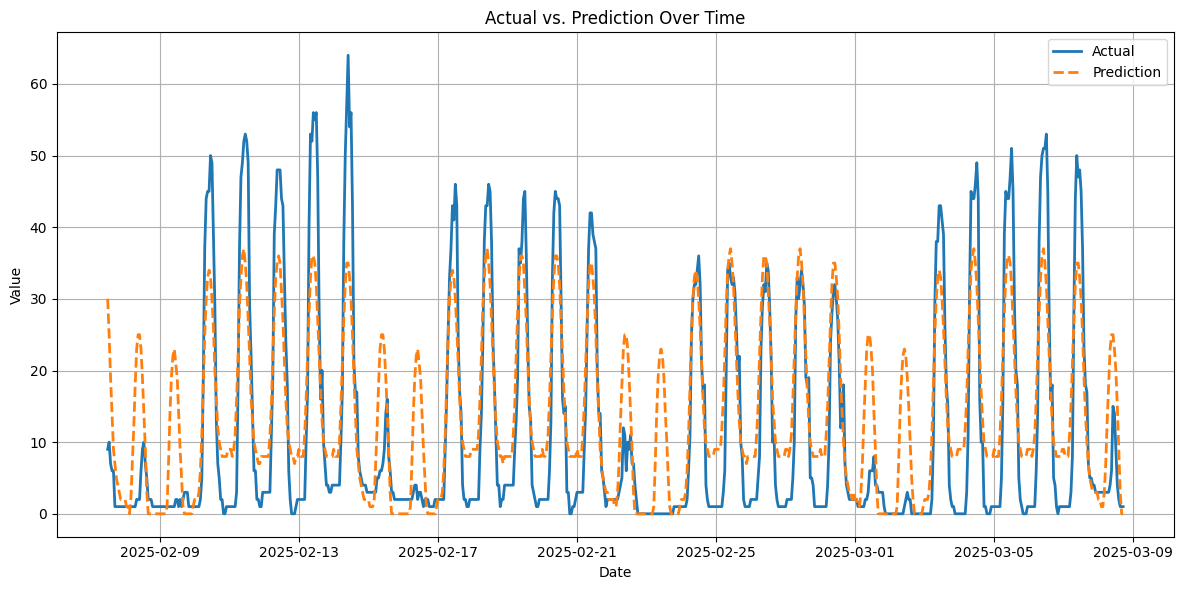

In [327]:
# Plot actual vs. prediction
plot_actual_vs_pred(df_diffs)

## Puutarhakatu 6

In [328]:
# Load actual data
df_actual = pd.read_csv("../data/pysakoinnit_2025_02_7-2025-03-09.csv") # all zones
df_actual = df_actual[df_actual['parking_area_id'] == '318a1ad2-5e33-488c-85bb-c3e9644c4942'] # puutarhakatu 6
# time format "2025-02-07 14:51:10.457393+00"
df_actual['time_start'] = pd.to_datetime(df_actual['time_start'], format="ISO8601")
df_actual['time_end'] = pd.to_datetime(df_actual['time_end'], format="ISO8601")

In [329]:
# Generate hourly timestamps for each hour eg 0, 1, 2
hourly_index = pd.date_range(start=df_actual['time_start'].min().floor('h'),
                             end=df_actual['time_end'].max().ceil('h'),
                             freq='h')

# Initialize an empty DataFrame for hourly occupancy counts
actual_hourly_parking = pd.DataFrame({'ds': hourly_index})

# Count active parkings in each hour
def count_active_parkings(timestamp):
    return ((df_actual['time_start'] <= timestamp) & (df_actual['time_end'] > timestamp)).sum()
    # time stamp is between start and end time of parking

actual_hourly_parking['y'] = actual_hourly_parking['ds'].apply(count_active_parkings)
actual_hourly_parking['ds'] = actual_hourly_parking['ds'].dt.tz_localize(None)
actual_hourly_parking.tail()

,ds,y
718,2025-03-09 09:00:00,1
719,2025-03-09 10:00:00,2
720,2025-03-09 11:00:00,1
721,2025-03-09 12:00:00,1
722,2025-03-09 13:00:00,0


In [330]:
# Load prediction data
df_prediction = pd.read_csv("./data/puutarhakatu6_baseline_forecast.csv")
df_prediction[["ds", "yhat"]].tail()

,ds,yhat
7014,2025-03-08 11:00:00,3.0
7015,2025-03-08 12:00:00,3.0
7016,2025-03-08 13:00:00,2.0
7017,2025-03-08 14:00:00,2.0
7018,2025-03-08 15:00:00,2.0


In [331]:
# filter actual and prediction dataframes
df_actual_filtered = actual_hourly_parking[(actual_hourly_parking["ds"] >= start_date) & (actual_hourly_parking["ds"] <= end_date)]
df_prediction_filtered = df_prediction[(df_prediction["ds"] >= start_date) & (df_prediction["ds"] <= end_date)]

In [332]:
# Calculate differences
df_diffs, avg_abs_diff, avg_percent_diff = calc_diffs(df_actual_filtered, df_prediction_filtered)

Average Absolute Difference: 0.88
Average Percentage Difference: 51.90%


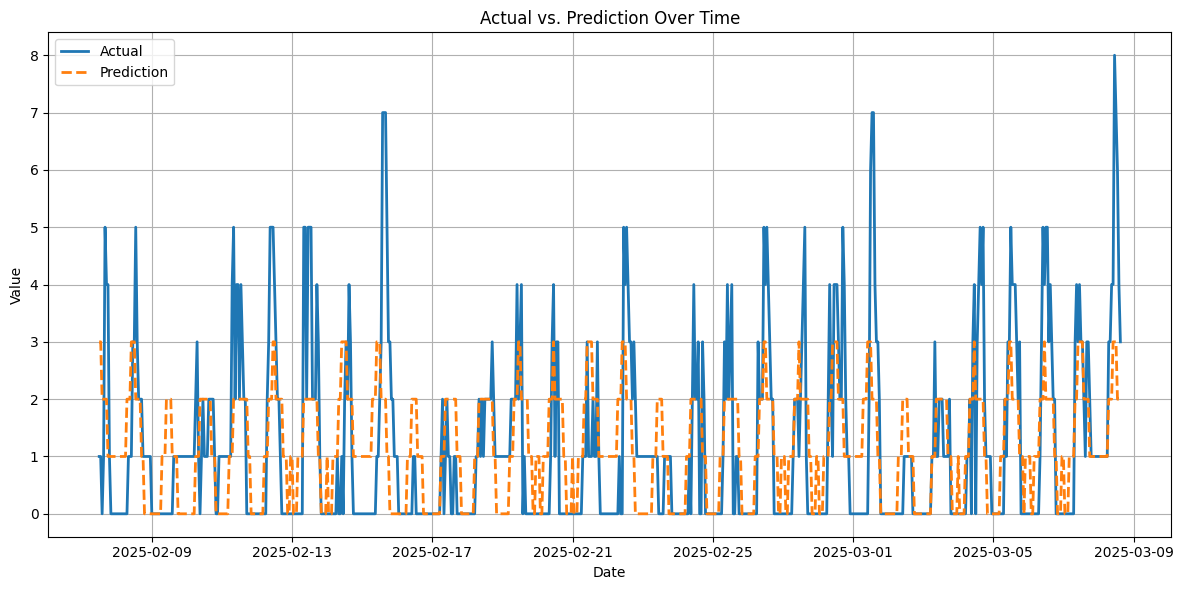

In [333]:
# Plot actual vs. prediction
plot_actual_vs_pred(df_diffs)